In [1]:
!pip uninstall -y keratorch

Found existing installation: keratorch 0.0.1
Uninstalling keratorch-0.0.1:
  Successfully uninstalled keratorch-0.0.1


In [2]:
!pip install git+https://github.com/JamorMoussa/keratorch.git

  Cloning https://github.com/JamorMoussa/keratorch.git to /tmp/pip-req-build-xg34ia34
  Running command git clone --filter=blob:none --quiet https://github.com/JamorMoussa/keratorch.git /tmp/pip-req-build-xg34ia34
  Resolved https://github.com/JamorMoussa/keratorch.git to commit 22a0108f344449c499be5c20785dec744ec7ed15
  Preparing metadata (setup.py) ... done
  Created wheel for keratorch: filename=keratorch-0.0.1-py3-none-any.whl size=6910 sha256=0069da6e9022992439f014607663c52a1f90ae3729f5f1cf3d7bb8ee073d8ac0
  Stored in directory: /tmp/pip-ephem-wheel-cache-afyob45o/wheels/92/7f/94/34475bcf38ef6f5980da5eb3ce78ff6ebdd8aebb2d30325b80
Successfully built keratorch


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms


import keratorch as kt

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


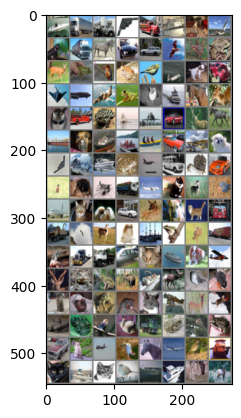

ship  truck truck plane truck ship  cat   ship  cat   truck horse car   car   bird  frog  frog  deer  frog  bird  frog  bird  plane dog   car   plane plane plane frog  cat   ship  horse deer  cat   truck frog  ship  plane car   deer  horse ship  dog   ship  ship  ship  car   plane dog   plane ship  ship  frog  plane car   frog  car   bird  dog   plane truck plane cat   deer  bird  plane cat   dog   car   deer  dog   cat   truck truck bird  deer  dog   ship  frog  bird  truck bird  truck truck car   cat   ship  dog   plane deer  frog  frog  deer  ship  deer  bird  cat   cat   cat   frog  cat   cat   plane deer  cat   cat   frog  bird  cat   truck frog  bird  frog  car   cat   plane bird  horse plane bird  ship  cat   ship  cat   bird  ship  ship  deer  deer 


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [6]:
# class Net(kt.nn.ktModule):
#     def __init__(self):
#         super().__init__()
#         self.conv1 = nn.Conv2d(3, 6, 5)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.conv2 = nn.Conv2d(6, 16, 5)
#         self.fc1 = nn.Linear(16 * 5 * 5, 120)
#         self.fc2 = nn.Linear(120, 84)
#         self.fc3 = nn.Linear(84, 10)

#     def forward(self, x):
#         x = self.pool(F.relu(self.conv1(x)))
#         x = self.pool(F.relu(self.conv2(x)))
#         x = torch.flatten(x, 1) # flatten all dimensions except batch
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x

In [7]:
# net = Net()

In [8]:
def log(x):
  print(x.shape)
  return x

In [9]:
net = kt.nn.Sequential(
            nn.Conv2d(3, 6, 3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 84),
            nn.ReLU(),
            nn.Linear(84, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

In [10]:
net

Sequential(
  (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1152, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=32, bias=True)
  (12): ReLU()
  (13): Linear(in_features=32, out_features=10, bias=True)
)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = kt.optim.Adam(lr=0.001)

In [12]:
net.compile(
  loss_fn= criterion,
  optimizer= optimizer,
  callbacks= [
      kt.callbacks.LossCallback(),
  ],
  device= torch.device("cuda")
)

In [13]:
hist = net.fit(trainloader= trainloader, num_iters=10, verbose_iter=500)

Epoch: [0/10] | loss: 1.34845: 100%|██████████| 391/391 [00:13<00:00, 28.92it/s]
Epoch: [1/10] | loss: 1.16872: 100%|██████████| 391/391 [00:12<00:00, 30.22it/s]
Epoch: [2/10] | loss: 1.10139: 100%|██████████| 391/391 [00:13<00:00, 28.97it/s]
Epoch: [3/10] | loss: 1.09114: 100%|██████████| 391/391 [00:13<00:00, 29.80it/s]
Epoch: [4/10] | loss: 0.96069: 100%|██████████| 391/391 [00:14<00:00, 27.52it/s]
Epoch: [5/10] | loss: 0.94428: 100%|██████████| 391/391 [00:13<00:00, 29.47it/s]
Epoch: [6/10] | loss: 0.90414: 100%|██████████| 391/391 [00:13<00:00, 29.30it/s]
Epoch: [7/10] | loss: 0.85656: 100%|██████████| 391/391 [00:13<00:00, 29.02it/s]
Epoch: [8/10] | loss: 0.81756: 100%|██████████| 391/391 [00:13<00:00, 29.35it/s]
Epoch: [9/10] | loss: 0.73192: 100%|██████████| 391/391 [00:13<00:00, 29.24it/s]


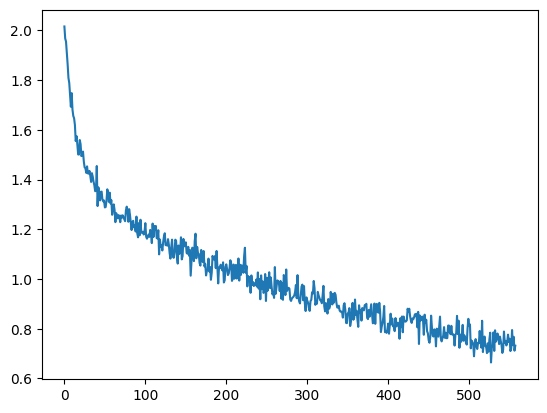

In [14]:
plt.plot(hist.history["train_loss"])

In [15]:
def compute_accuracy(model, loader: torch.utils.data.DataLoader):
  acc = 0
  for x, y in loader:
    res = model(x.to("cuda")).argmax(dim=1)
    acc += (res.detach().cpu() == y).sum()

  acc = acc.item()/len(loader)
  return acc/loader.batch_size

In [16]:
compute_accuracy(
    model=net,
    loader= trainloader
)

0.7148737212276215

In [17]:
compute_accuracy(
    model=net,
    loader= testloader
)

0.6259889240506329